# Perceptron

(인공뉴런, Rosenblatt's Perceptron)

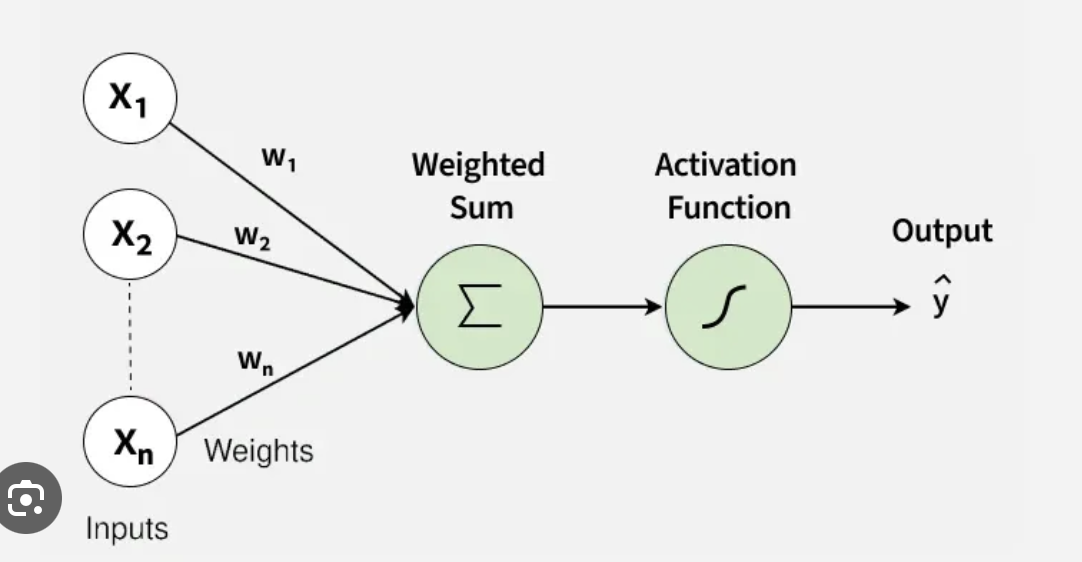

여기서 input과 곱해지는 Weight (가중치) 를 찾는것이 목표

## XOR 사용해서 문제 해결

NAND, OR AND

# Neural Network

: Perceptron이 여러개.

# MLP (Multi Layer Perceptron)

비선형 문제를 풀기 위해 필요

여러 layer일수록 비선형

layer : 각 단계

입력 layer : 맨앞

출력 layer : 맨뒤

hidden layer : 은닉층 (입력층과 출력층 사이 layer들)

## Backpropagation (오차역전파)

mlp를 학습시키기 위해 등장한 개념.

일반적인 계산 방식의 순서 : Forward Propagation (순전파)

순전파를 계산한 다음, 최종 오차부터 거꾸로 오면서 맨 마지막 weight을 조금씩 바꿈. 그렇게 맨 처음을 향하는 도미노처럼 weight이 조금씩 바뀌면, 다시 순전파를 계산해서 새로운 오차를 계산.



weight 바꾸는 방식 : 오차를 해당 단계의 weight으로 미분함. 거기에 learning rate을 곱하고, 원래 weight에서 빼면,
그게 새로운 weight

이때 미분하는 weight : 그 weight이 해당 오차에 얼마나 영향을 미치는지 알수있음
BUT 미분할때는 뒤에서부터 순서대로 미분해줘야 함 (Chain Rule)


이때 오차가 미분 가능해야 하므로, 계단 함수가 아닌 sigmoid 함수를 사용.

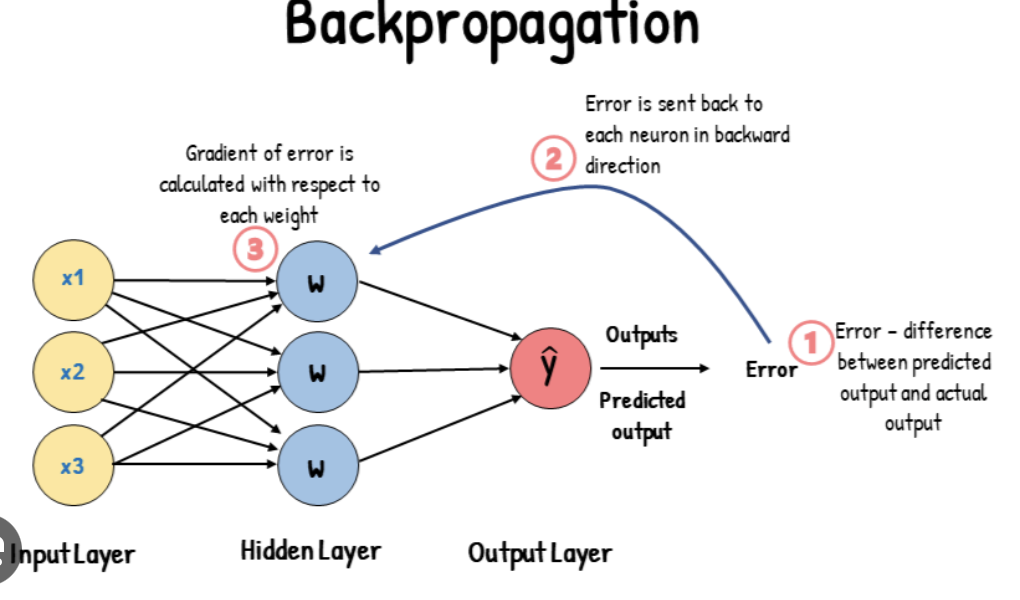

## Gradient Vanishing (기울기 소실)

Deep Neural Network의 경우, backpropagation하면서 앞으로 갈수록 오차를 미분하면 그 값이 계속 작아지므로 학습이 되지 않음 (거의 0이 되버림)

*** 따라서 sigmoid를 사용하지 않기로 함. ***

*** RELU 함수를 활성화함수로 사용하기로 함. ***

## ReLU


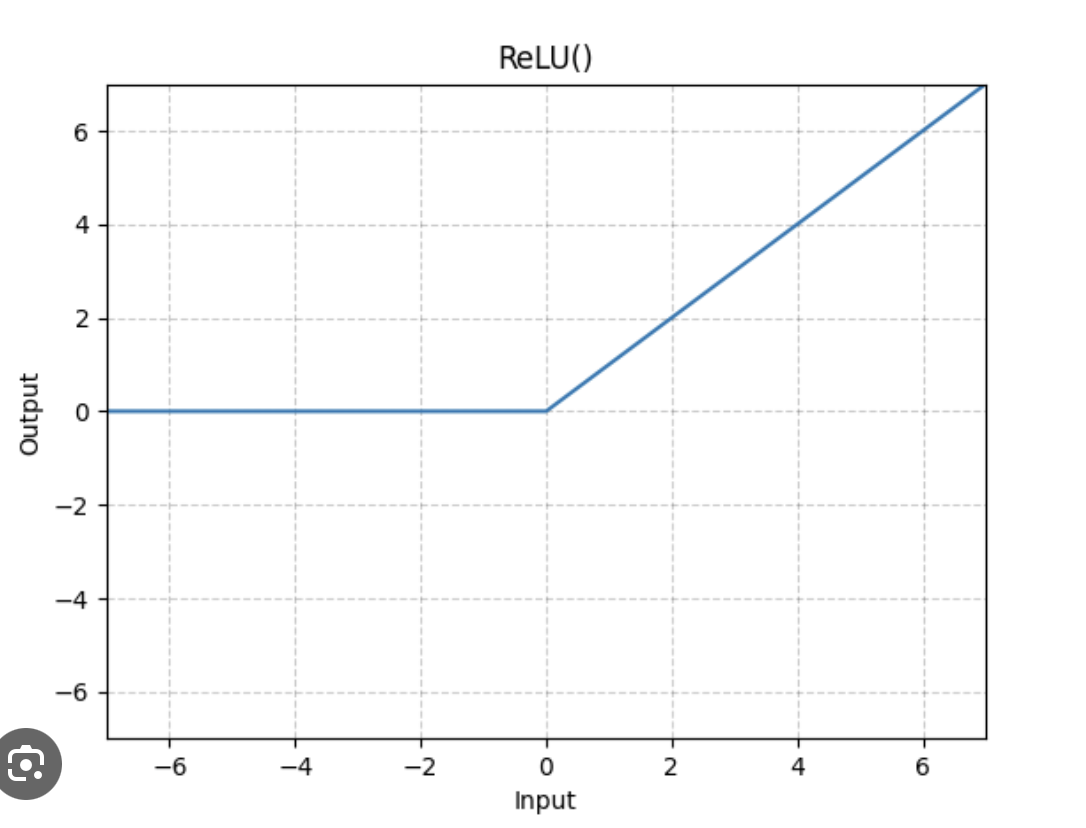

# DEEP LEARNING

##  :  MLP (Multi Layer Perceptron, 다층 신경망) 을 안정적으로 학습시킬수 있는 알고리즘


Batch : 모든 데이터를 한번 집어넣어서 계산한것 (사용 안함)

Mini batch : 데이터를 조금씩 쪼개서 집어넣은것

## Optimizer (최적화 함수)
## : (원래 weight) - { (오차를 미분한거) * optimizer }

loss function 의 최솟값을 찾는 것.

Adam을 많이 사용

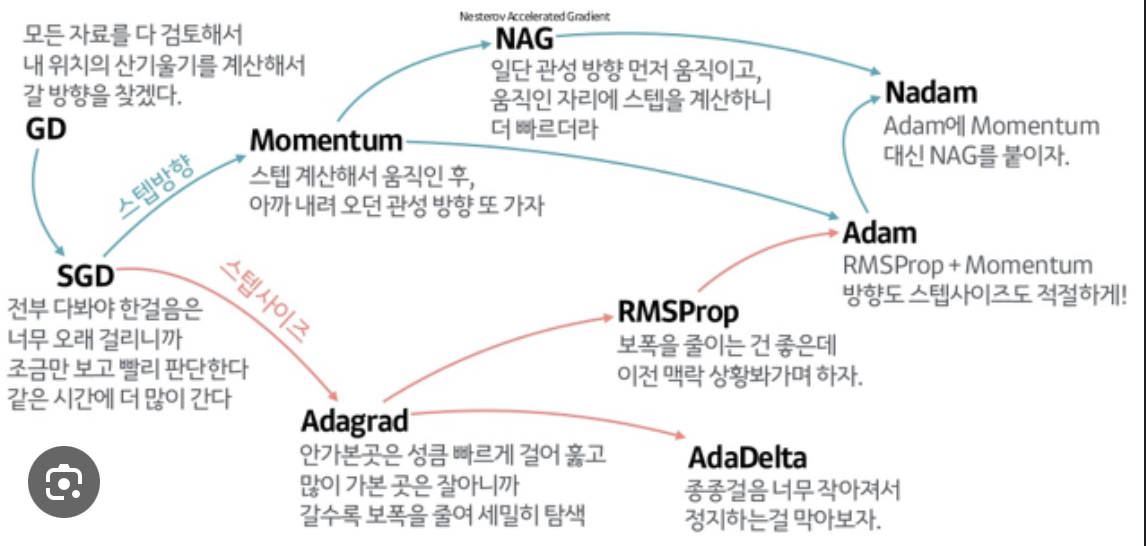

## Batch Normalization (정규화)

데이터를 여러 batch로 나눠서 학습시킬건데, 한 batch 안의 데이터가 너무 치우쳐있으면 안되니까 그 input 값들을 정규화시킴

Early Stopping : overfitting 되기 직전에 학습을 멈춤.

# **********실습 Regression******************

이전에 Linear Regression에서 했던 auto mpg 데이터 그대로

In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [69]:
import tensorflow as tf
import keras
keras.utils.set_random_seed(SEED)

## 데이터

전처리까지는 전에 했던거 그대로

In [70]:
autom = pd.read_csv('https://raw.githubusercontent.com/devdio/flyai_datasets/refs/heads/main/auto-mpg.csv')

In [71]:
autom.shape

(398, 9)

In [72]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(autom, test_size=0.2, random_state=SEED, shuffle=True)
x_train = train.drop(['mpg', 'car name'], axis=1)
y_train = train['mpg']

In [73]:
x_train['horsepower'] = x_train['horsepower'].replace('?', np.nan)
x_train['horsepower'] = x_train['horsepower'].astype('float')

In [74]:
m = x_train['horsepower'].mean()
x_train['horsepower'] = x_train['horsepower'].fillna(m)

In [75]:
from sklearn.preprocessing import OneHotEncoder

x_categorical_cols = ['cylinders', 'model year', 'origin']
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
x_ohe = pd.DataFrame(
                    data = ohe.fit_transform(x_train[x_categorical_cols]),
                    columns = ohe.get_feature_names_out(x_categorical_cols),
                    index = x_train.index
                    )

x_train_e = pd.concat([x_train.drop(x_categorical_cols, axis=1), x_ohe], axis=1)

In [76]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(x_train_e)
x_train_es = scaler.transform(x_train_e)

In [77]:
y_train = np.log1p(y_train)

### 최종 데이터

In [78]:
x_train_es.shape, y_train.shape

((318, 25), (318,))

## 모델 정의

In [79]:
from keras import layers

### 회귀모델이므로 출력은 1개, 활성화함수 없음

In [80]:
model = keras.Sequential(
    [
        keras.Input(shape=(25,)),   # column 개수
        layers.Dense(units=64, activation='relu'),
        layers.Dense(units=32, activation='relu'),
        layers.Dense(units=1)
    ]
)

In [81]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_11 (Dense)                │ (None, 64)             │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,777 (14.75 KB)

 Trainable params: 3,777 (14.75 KB)

 Non-trainable params: 0 (0.00 B)

## 컴파일

cost function, optimizer, metrics

In [82]:
model.compile(
    optimizer = 'adam',
    loss = 'mse',
    metrics = ['mse']
)

## EPOCH : 반복 횟수

In [83]:
EPOCHS = 500

history = model.fit(
    x_train_es, y_train,
    epochs = EPOCHS,
    batch_size = 16,
    validation_split = 0.2
)

Epoch 1/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 8.2075 - mse: 8.2075 - val_loss: 5.3943 - val_mse: 5.3943
Epoch 2/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 3.0097 - mse: 3.0097 - val_loss: 1.5837 - val_mse: 1.5837
Epoch 3/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.7768 - mse: 0.7768 - val_loss: 0.4040 - val_mse: 0.4040
Epoch 4/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.3734 - mse: 0.3734 - val_loss: 0.2359 - val_mse: 0.2359
Epoch 5/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2213 - mse: 0.2213 - val_loss: 0.1799 - val_mse: 0.1799
Epoch 6/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.1526 - mse: 0.1526 - val_loss: 0.1407 - val_mse: 0.1407
Epoch 7/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.1165 - mse: 0.1165 - val_loss: 0.1043 - val_mse: 0.1043
Epoch 8/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0939 - mse: 0.0939 - val_loss: 0.0889 - val_mse: 0.0889
Epoch 9/500
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0

### 학습 결과 그래프

In [84]:
def plot_loss(history):
  plt.plot(history.history['loss'], label='loss')
  plt.plot(history.history['val_loss'], label='val_loss')
  plt.xlabel('Epoch')
  plt.ylabel('Error [MPG]')
  plt.legend()
  plt.grid(True)

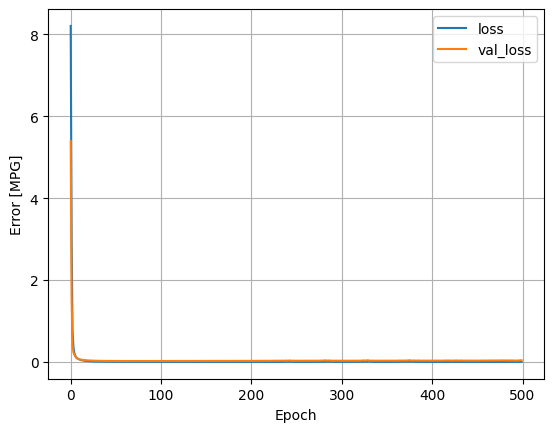

In [85]:
plot_loss(history)

## 테스트

In [86]:
x_test = test.drop(['mpg', 'car name'], axis=1)
y_test = test['mpg']

In [87]:
x_test['horsepower'] = x_test['horsepower'].replace('?', np.nan)
x_test['horsepower'] = x_test['horsepower'].astype('float')

In [88]:
x_test['horsepower'] = x_test['horsepower'].fillna(m)

In [89]:
x_ohe_test = pd.DataFrame(
                    data = ohe.transform(x_test[x_categorical_cols]),
                    columns = ohe.get_feature_names_out(x_categorical_cols),
                    index = x_test.index
                    )

x_test_e = pd.concat([x_test.drop(x_categorical_cols, axis=1), x_ohe_test], axis=1)

In [90]:
x_test_es = scaler.transform(x_test_e)

### 돌려보기

In [91]:
y_pred = model.predict(x_test_es)
y_pred = y_pred.reshape(-1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


## 결과 확인

### 로그 역변환

In [92]:
y_pred = np.expm1(y_pred)
y_pred

array([30.61934  , 28.12345  , 21.440685 , 15.690136 , 13.808999 ,
       27.316586 , 26.208145 , 14.41471  , 15.365985 , 19.287748 ,
       16.450476 , 32.15504  , 30.847221 , 15.966683 , 17.496506 ,
       13.014475 , 30.019154 , 16.528559 , 16.125278 , 33.272655 ,
       19.609547 , 19.710007 , 41.326527 , 28.12449  , 19.959116 ,
       30.35092  , 23.522158 , 23.294643 , 20.222887 , 13.6824045,
       26.63752  , 29.158484 , 18.841753 , 24.912401 , 36.34756  ,
       13.853238 , 22.9067   , 22.127203 , 14.777607 , 20.81454  ,
       29.039774 , 29.246225 , 19.432695 , 11.74983  , 22.916359 ,
       30.427418 , 21.622448 , 17.70688  , 19.280794 , 27.595764 ,
       23.325253 , 23.888641 , 31.385057 , 13.257054 , 39.55329  ,
       13.552905 , 18.019533 , 28.493582 , 23.076942 , 20.629803 ,
       14.3719425, 28.705286 , 22.690838 , 15.12098  , 20.422565 ,
       23.249899 , 21.346792 , 29.914698 , 24.995598 , 14.302097 ,
       28.95988  , 15.183752 , 15.4622755, 18.787632 , 44.4389

### 그래프 그리기

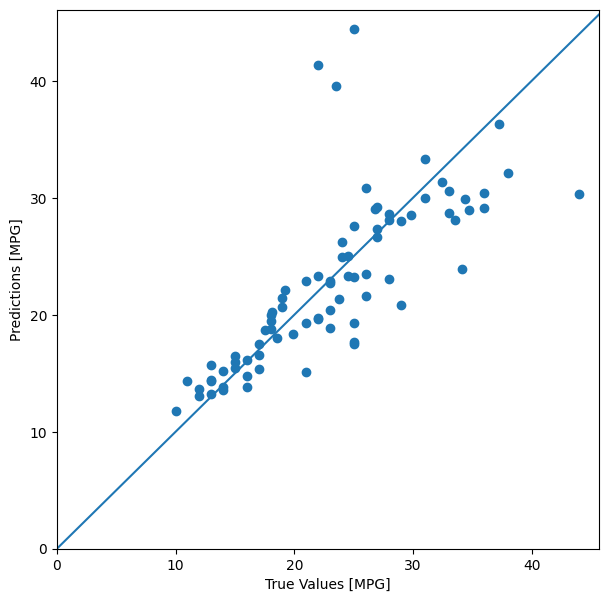

In [93]:
plt.figure(figsize=(7, 7))
plt.scatter(y_test, y_pred)
plt.xlabel('True Values [MPG]')
plt.ylabel('Predictions [MPG]')
plt.xlim([0, plt.xlim()[1]])
plt.ylim([0, plt.ylim()[1]])
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val])
plt.show()

# **********실습 Binary Classification*************

## 데이터

In [123]:
diabetes = pd.read_csv('https://raw.githubusercontent.com/devdio/flyai_datasets/refs/heads/main/diabetes.csv')

In [124]:
from sklearn.model_selection import train_test_split
train, test = train_test_split(diabetes, test_size=0.2, random_state=SEED, stratify=diabetes['Outcome'], shuffle=True)
x_train = train.drop('Outcome', axis=1)
y_train = train['Outcome']

In [125]:
temp_cols = ['BMI', 'Insulin', 'SkinThickness', 'BloodPressure', 'Glucose']

x_train[temp_cols] = x_train[temp_cols].replace(0, np.nan)

mean_values = {}
for col in temp_cols:
  u = x_train[col].mean()
  x_train[col] = x_train[col].fillna(u)
  mean_values[col] = u

In [126]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_s = scaler.fit_transform(x_train)
y_train = y_train.to_numpy()

### 최종 데이터

In [127]:
x_train_s.shape, y_train.shape

((614, 8), (614,))

## 모델정의

In [128]:
model = keras.Sequential(
    [
        keras.Input(shape=(8,)),   # column 개수
        layers.Dense(units=64, activation = 'relu'),
        layers.Dense(units=32, activation = 'relu'),
        layers.Dense(units=1, activation = 'sigmoid')
    ]
)

### Binary Classificaiton 이므로 마지막 출력 layer의 activation 함수는 sigmoid

## 컴파일

In [129]:
model.compile(
    optimizer = 'adam',
    loss = 'binary_crossentropy',
    metrics = ['accuracy']
)

## EPOCH

In [130]:
EPOCHS = 200

history = model.fit(
    x_train_s, y_train,
    epochs = EPOCHS,
    batch_size = 16,
    validation_split = 0.2
)

Epoch 1/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.7495 - loss: 0.5867 - val_accuracy: 0.7480 - val_loss: 0.5217
Epoch 2/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7821 - loss: 0.4866 - val_accuracy: 0.7805 - val_loss: 0.4727
Epoch 3/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7862 - loss: 0.4539 - val_accuracy: 0.7967 - val_loss: 0.4538
Epoch 4/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7882 - loss: 0.4401 - val_accuracy: 0.7886 - val_loss: 0.4459
Epoch 5/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7882 - loss: 0.4317 - val_accuracy: 0.7886 - val_loss: 0.4416
Epoch 6/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7984 - loss: 0.4254 - val_accuracy: 0.7886 - val_loss: 0.4393
Epoch 7/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7963 - loss: 0.4203 - val_accuracy: 0.7967 - val_loss: 0.4383
Epoch 8/200
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8086 - loss: 0.4159 - val_accuracy: 0.7967 - 

### 학습 결과 그래프

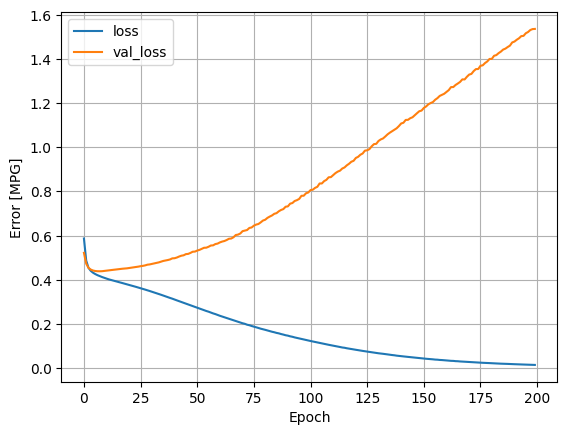

In [131]:
plot_loss(history)

## 테스트

In [132]:
x_test = test.drop('Outcome', axis=1)
y_test = test['Outcome']

x_test[temp_cols] = x_test[temp_cols].replace(0, np.nan)
for col in temp_cols:
    x_test[col] = x_test[col].fillna(mean_values[col])

In [133]:
x_test_s = scaler.transform(x_test)
y_test = y_test.to_numpy()

### 돌려보기

In [134]:
y_pred = model.predict(x_test_s)
y_pred = y_pred.reshape(-1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


나중에 모델 loading 했다면 y_pred = loaded_model.predict(x_test_s)

## 결과 확인

### 그래프 그리기

In [138]:
import matplotlib.pyplot as plt

def plot_history(history):
  hist = pd.DataFrame(history.history)
  hist['epoch'] = history.epoch

  plt.figure(figsize=(16,8))

  plt.subplot(1,2,1)
  plt.xlabel('Epoch')
  plt.ylabel('Loss')
  plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
  plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
  plt.legend()

  plt.subplot(1,2,2)
  plt.xlabel('Epoch')
  plt.ylabel('Accuracy')
  plt.plot(hist['epoch'], hist['accuracy'], label='Train Accuracy')
  plt.plot(hist['epoch'], hist['val_accuracy'], label = 'Val Accuracy')

  plt.legend()
  plt.show()

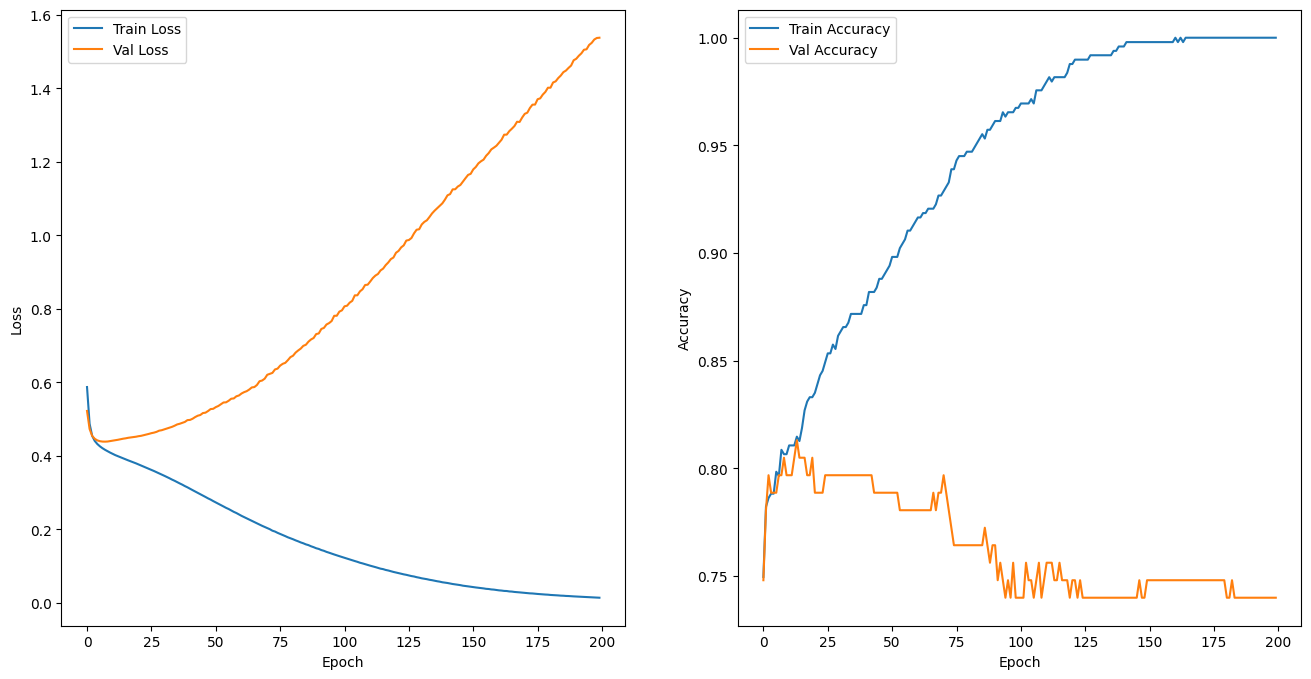

In [139]:
plot_history(history)

## 모델 저장

In [141]:
model.save('neuralnetwork_binary_classification.keras')

## 모델 로딩

In [143]:
loaded_model = keras.models.load_model('neuralnetwork_binary_classification.keras')
loaded_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_23 (Dense)                │ (None, 64)             │           576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,069 (31.52 KB)

 Trainable params: 2,689 (10.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,380 (21.02 KB)